In [ ]:
# ============================================================
# GRAPH 1: OVERALL PRICE DISTRIBUTION
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Basic statistical summary

df=pd.read_excel(r"csv_Final_Bosss.xlsx")
print("PRICE SUMMARY")
print(df["Price"].describe())


# 2. Important percentiles
print("\nPRICE PERCENTILES")
print(df["Price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))


# 3. Plot price distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Price",
    bins=40
)

plt.xlabel("Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Distribution of Mission Prices")

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# SPACE MISSION PRICE ANALYSIS - 5 GRAPHS
# ============================================================


# ============================================================
# GRAPH 1: OVERALL PRICE DISTRIBUTION
# ============================================================

print("PRICE SUMMARY")
print(df["Price"].describe())

print("\nPRICE PERCENTILES")
print(df["Price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Price",
    bins=40
)

plt.xlabel("Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Distribution of Mission Prices")

plt.show()


# ============================================================
# GRAPH 2: PRICE VS DECADE
# ============================================================

decade_summary = df.groupby("Decade").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

print("\nPRICE BY DECADE")
print(decade_summary)

plt.figure(figsize=(10, 5))

plt.plot(
    decade_summary.index,
    decade_summary["Median_Price"],
    marker="o",
    label="Median"
)

plt.plot(
    decade_summary.index,
    decade_summary["Mean_Price"],
    marker="o",
    label="Mean"
)

plt.xlabel("Decade")
plt.ylabel("Mission Price ($ million)")
plt.title("Mean vs Median Mission Price Across Decades")

plt.xticks(decade_summary.index)
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# GRAPH 3: ORGANISATION - COST VS VOLUME
# ============================================================

org_summary = df.groupby("Organisation").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean"),
    Std_Price=("Price", "std")
)

# Keep organisations with at least 10 missions
org_summary = org_summary[
    org_summary["Missions"] >= 10
]

print("\nORGANISATION COST-VOLUME ANALYSIS")
print(org_summary.sort_values("Median_Price", ascending=False))


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=org_summary,
    x="Median_Price",
    y="Missions",
    size="Missions",
    legend=False
)

plt.xlabel("Median Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Mission Volume vs Typical Mission Cost")

plt.grid(True)

plt.show()


# ============================================================
# GRAPH 4: PRICE VS MISSION OUTCOME
# ============================================================

print("\nMISSION STATUS COUNTS")
print(df["Mission_Status"].value_counts())

status_summary = df.groupby("Mission_Status").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

print("\nPRICE BY MISSION STATUS")
print(status_summary)


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Mission_Status",
    y="Price"
)

plt.xlabel("Mission Status")
plt.ylabel("Mission Price ($ million)")
plt.title("Mission Price Distribution by Mission Outcome")

plt.xticks(rotation=20)

plt.show()


# ============================================================
# GRAPH 5: COST × VOLUME × SUCCESS
# ============================================================

period_summary = df.groupby("Decade").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

# Calculate successful missions
success_count = df[df["Mission_Status"] == "Success"].groupby("Decade").size()

period_summary["Success_Rate"] = (
    success_count / period_summary["Missions"] * 100
)

period_summary["Success_Rate"] = period_summary["Success_Rate"].fillna(0)

print("\nDECADE COST-VOLUME-SUCCESS ANALYSIS")
print(period_summary)


# Bubble/scatter-style analysis
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=period_summary,
    x="Median_Price",
    y="Missions",
    size="Success_Rate",
    sizes=(50, 500),
    legend=True
)

plt.xlabel("Median Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Mission Cost, Volume and Success Across Decades")

plt.grid(True)

plt.show()

“The objective of this analysis is to study historical space mission data and identify patterns in mission costs, mission frequency, organisational performance, and mission outcomes. The aim is to understand how mission costs have varied over time and across organisations, and whether cost appears to be associated with mission success.”

The first major observation is that mission prices are highly uneven. The median mission cost is around $200 million, whereas the mean is around $2.13 billion. This large difference indicates that high-cost observations are strongly affecting the average. Therefore, the median gives us a better picture of the typical mission cost.

However, I also observed a very large concentration of values at exactly $5 billion. So before drawing a strong financial conclusion, I need to investigate whether these values represent actual mission costs or values introduced during the missing-value treatment

The decade-wise analysis shows that mission prices were considerably higher in the 1960s, 1970s and 1980s, while the median price drops sharply from the 1990s onwards. This suggests a major change in the recorded cost profile of space missions over time.
But because the $5 billion value is heavily concentrated in some periods, I don't want to interpret this directly as proof that space missions became cheaper. I need to investigate the composition of those values first.

In [ ]:
# ============================================================
# GRAPH 1: OVERALL PRICE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Price summary
print("PRICE SUMMARY")
print(df["Price"].describe())

print("\nPRICE PERCENTILES")
print(df["Price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))

# Graph
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Price",
    bins=40
)

plt.xlabel("Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Distribution of Mission Prices")

plt.show()


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "="*70)
print("PROBLEM STATEMENT")
print("="*70)

print("""
What does the overall financial distribution of space mission
costs look like, and is the mean or median a better representation
of a typical mission cost?
""")


print("\n" + "="*70)
print("ANALYSIS")
print("="*70)

print("""
The price distribution is highly uneven. The median mission cost
is around $200 million, while the mean is approximately $2.13 billion.
There is also a very large concentration of observations at exactly
$5 billion.

This indicates that high-value observations are strongly influencing
the mean and that the median provides a more representative view of
the typical mission cost.
""")


print("\n" + "="*70)
print("ANSWER / INFERENCE")
print("="*70)

print("""
The median is a more suitable measure of typical mission cost than
the mean because the distribution is heavily influenced by extremely
high values. However, the large concentration at exactly $5 billion
needs further investigation before making strong financial conclusions.
""")

In [ ]:
# ============================================================
# GRAPH 2: PRICE VS DECADE
# ============================================================

decade_summary = df.groupby("Decade").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

print("PRICE BY DECADE")
print(decade_summary)


# Graph
plt.figure(figsize=(10, 5))

plt.plot(
    decade_summary.index,
    decade_summary["Median_Price"],
    marker="o",
    label="Median"
)

plt.plot(
    decade_summary.index,
    decade_summary["Mean_Price"],
    marker="o",
    label="Mean"
)

plt.xlabel("Decade")
plt.ylabel("Mission Price ($ million)")
plt.title("Mean vs Median Mission Price Across Decades")

plt.xticks(decade_summary.index)
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "="*70)
print("PROBLEM STATEMENT")
print("="*70)

print("""
How has the typical cost of space missions changed across
different decades?
""")


print("\n" + "="*70)
print("ANALYSIS")
print("="*70)

print("""
The decade-wise analysis shows substantially higher recorded
mission costs during the 1960s, 1970s and 1980s.

From the 1990s onward, the median mission price drops sharply
and remains considerably lower during the 2000s, 2010s and 2020s.

The mean is generally higher than the median, indicating that
high-priced missions continue to influence the average.
""")


print("\n" + "="*70)
print("ANSWER / INFERENCE")
print("="*70)

print("""
The data indicates a major change in the recorded mission-cost
profile over time, with typical mission costs appearing much lower
in the later decades.

However, this should not immediately be interpreted as proof that
space missions became cheaper, because the large concentration of
$5 billion values may be influencing the historical pattern.
Further investigation of these values is required.
""")

In [ ]:
# ============================================================
# GRAPH 3: ORGANISATION - COST VS VOLUME
# ============================================================

org_summary = df.groupby("Organisation").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean"),
    Std_Price=("Price", "std")
)

# Keep organisations with at least 10 missions
org_summary = org_summary[
    org_summary["Missions"] >= 10
]

print("ORGANISATION COST-VOLUME ANALYSIS")
print(org_summary.sort_values("Median_Price", ascending=False))


# Graph
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=org_summary,
    x="Median_Price",
    y="Missions",
    size="Missions",
    legend=False
)

plt.xlabel("Median Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Mission Volume vs Typical Mission Cost")

plt.grid(True)

plt.show()


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "="*70)
print("PROBLEM STATEMENT")
print("="*70)

print("""
Do different organisations show different cost-volume profiles,
and are there organisations that combine relatively low typical
mission costs with high mission volume?
""")


print("\n" + "="*70)
print("ANALYSIS")
print("="*70)

print("""
The analysis shows substantial differences in mission volume
across organisations.

Most organisations are concentrated in the lower-volume region,
while a small number of organisations have conducted significantly
more missions.

Comparing mission volume with median price allows us to investigate
whether high operational activity is associated with relatively
lower typical mission costs.
""")


print("\n" + "="*70)
print("ANSWER / INFERENCE")
print("="*70)

print("""
The data reveals clear differences in organisational mission volume
and provides a useful cost-volume comparison.

However, high mission volume alone cannot be considered proof of
cost efficiency or profitability. Mission type, complexity, payload,
and organisational objectives would also need to be considered.
""")

In [ ]:
# ============================================================
# GRAPH 4: PRICE VS MISSION OUTCOME
# ============================================================

print("MISSION STATUS COUNTS")
print(df["Mission_Status"].value_counts())


status_summary = df.groupby("Mission_Status").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

print("\nPRICE BY MISSION STATUS")
print(status_summary)


# Graph
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Mission_Status",
    y="Price"
)

plt.xlabel("Mission Status")
plt.ylabel("Mission Price ($ million)")
plt.title("Mission Price Distribution by Mission Outcome")

plt.xticks(rotation=20)

plt.show()


# ============================================================
# PRICE BAND ANALYSIS
# ============================================================

df["Price_Band"] = pd.qcut(
    df["Price"],
    q=4,
    duplicates="drop"
)

success_by_price = pd.crosstab(
    df["Price_Band"],
    df["Mission_Status"],
    normalize="index"
) * 100

print("\nMISSION OUTCOME PERCENTAGE BY PRICE BAND")
print(success_by_price.round(2))


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "="*70)
print("PROBLEM STATEMENT")
print("="*70)

print("""
Is higher mission expenditure associated with different
mission outcomes?
""")


print("\n" + "="*70)
print("ANALYSIS")
print("="*70)

print("""
The mission-status comparison examines the median, mean and
distribution of mission prices across different outcomes.

The price-band analysis additionally compares the percentage
distribution of mission outcomes across different cost groups.

This allows us to determine whether mission outcomes appear to
change as mission cost increases.
""")


print("\n" + "="*70)
print("ANSWER / INFERENCE")
print("="*70)

print("""
FINAL INFERENCE TO BE COMPLETED AFTER OBSERVING THE RESULT:

Compare the success rate and price distribution across the
different price bands.

If higher-priced groups show higher success rates, this suggests
an association between higher expenditure and mission success.

If the success rates are similar across price groups, then higher
spending does not show a clear advantage in this dataset.

This represents association, not causation.
""")

In [ ]:
# ============================================================
# GRAPH 5: COST × VOLUME × SUCCESS
# ============================================================

period_summary = df.groupby("Decade").agg(
    Missions=("Price", "count"),
    Median_Price=("Price", "median"),
    Mean_Price=("Price", "mean")
)

# Count successful missions
success_count = (
    df[df["Mission_Status"] == "Success"]
    .groupby("Decade")
    .size()
)

# Calculate success rate
period_summary["Success_Rate"] = (
    success_count / period_summary["Missions"] * 100
)

period_summary["Success_Rate"] = (
    period_summary["Success_Rate"].fillna(0)
)

print("DECADE COST-VOLUME-SUCCESS ANALYSIS")
print(period_summary.round(2))


# Graph
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=period_summary,
    x="Median_Price",
    y="Missions",
    size="Success_Rate",
    sizes=(50, 500)
)

plt.xlabel("Median Mission Price ($ million)")
plt.ylabel("Number of Missions")
plt.title("Mission Cost, Volume and Success Across Decades")

plt.grid(True)

plt.show()


# ============================================================
# INTERPRETATION
# ============================================================

print("\n" + "="*70)
print("PROBLEM STATEMENT")
print("="*70)

print("""
Which periods show a potentially favourable balance between
typical mission cost, mission volume and mission success?
""")


print("\n" + "="*70)
print("ANALYSIS")
print("="*70)

print("""
This analysis combines three dimensions:

1. Median mission cost
2. Number of missions
3. Mission success rate

The objective is to identify periods where lower typical costs,
higher mission volume and stronger outcomes appear together.

This provides a broader cost-volume-outcome perspective than
looking at mission price alone.
""")


print("\n" + "="*70)
print("ANSWER / INFERENCE")
print("="*70)

print("""
The most interesting periods are those that combine relatively
lower median mission costs with higher mission volume and stronger
success rates.

Such periods can be considered potential cost-volume-outcome
patterns worthy of further investigation.

However, this analysis does not establish profitability or
causation because the dataset does not contain revenue, profit,
mission value or other economic variables.
""")

In [1]:
import pandas as pd

# Load CSV
df = pd.read_csv("Space_Mission_Data_Final.csv")

# Organisation count
org_counts = (
    df["Organisation"]
    .astype(str)
    .str.strip()
    .value_counts()
    .reset_index()
)

# Rename columns
org_counts.columns = ["Organisation", "Mission_Count"]

# Print
print("=" * 50)
print("ORGANISATION FREQUENCY")
print("=" * 50)

print(org_counts.to_string(index=False))

# Optional: save to CSV
org_counts.to_csv(
    "Organisation_Frequency.csv",
    index=False
)

print("\nSaved as: Organisation_Frequency.csv")

ORGANISATION FREQUENCY
    Organisation  Mission_Count
       RVSN USSR           1777
     Arianespace            279
            CASC            251
General Dynamics            251
            NASA            203
          VKS RF            201
    US Air Force            161
             ULA            140
          Boeing            136
 Martin Marietta            114
          SpaceX            100
             MHI             84
        Northrop             83
        Lockheed             79
            ISRO             76
       Roscosmos             55
             ILS             46
      Sea Launch             36
            ISAS             30
       Kosmotras             22
         US Navy             17
      Rocket Lab             13
             ISA             13
        Eurockot             13
             ESA             13
     Blue Origin             12
             IAI             11
          ExPace             10
             ASI              9
            CNES 

In [3]:
import pandas as pd

# Load original CSV with NULL prices
df = pd.read_csv(r"orignal.csv")

# ------------------------------------------------------------
# Clean Organisation names
# ------------------------------------------------------------

df["Organisation"] = (
    df["Organisation"]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# Price ko numeric banao
# Handles values like "5,000"
# ------------------------------------------------------------

df["Price_Clean"] = (
    df["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Price_Clean"] = pd.to_numeric(
    df["Price_Clean"],
    errors="coerce"
)

# ------------------------------------------------------------
# Organisation-wise Price analysis
# ------------------------------------------------------------

org_price = (
    df.groupby("Organisation")
    .agg(
        Total_Missions=("Price_Clean", "size"),
        Known_Price=("Price_Clean", "count"),
        Missing_Price=("Price_Clean", lambda x: x.isna().sum())
    )
    .reset_index()
)

# ------------------------------------------------------------
# Percentages
# ------------------------------------------------------------

org_price["Known_%"] = (
    org_price["Known_Price"]
    / org_price["Total_Missions"]
    * 100
)

org_price["Missing_%"] = (
    org_price["Missing_Price"]
    / org_price["Total_Missions"]
    * 100
)

# ------------------------------------------------------------
# Sort by total missions
# ------------------------------------------------------------

org_price = org_price.sort_values(
    "Total_Missions",
    ascending=False
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 90)
print("ORGANISATION-WISE PRICE AVAILABILITY")
print("=" * 90)

print(
    org_price.to_string(
        index=False,
        formatters={
            "Known_%": "{:.2f}%".format,
            "Missing_%": "{:.2f}%".format
        }
    )
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

org_price.to_csv(
    "Organisation_Price_Missingness.csv",
    index=False
)

print("\nSaved as: Organisation_Price_Missingness.csv")

ORGANISATION-WISE PRICE AVAILABILITY
    Organisation  Total_Missions  Known_Price  Missing_Price Known_% Missing_%
       RVSN USSR            1777            2           1775   0.11%    99.89%
     Arianespace             279           96            183  34.41%    65.59%
General Dynamics             251            0            251   0.00%   100.00%
            CASC             251          158             93  62.95%    37.05%
            NASA             203          149             54  73.40%    26.60%
          VKS RF             201           33            168  16.42%    83.58%
    US Air Force             161           26            135  16.15%    83.85%
             ULA             140           98             42  70.00%    30.00%
          Boeing             136            7            129   5.15%    94.85%
 Martin Marietta             114            9            105   7.89%    92.11%
          SpaceX             100           99              1  99.00%     1.00%
             MH

In [1]:
import pandas as pd
import numpy as np

# ============================================================
# 1. LOAD ORIGINAL DATASET
# ============================================================

file_path = r"orignal.csv"

df = pd.read_csv(file_path)

print("Original rows:", len(df))


# ============================================================
# 2. CLEAN PRICE
# ============================================================

df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)


# ============================================================
# 3. SAVE ORIGINAL PRICE
# ============================================================

# This is our safety copy.
df["Price_Original"] = df["Price"]


# ============================================================
# 4. REAL-WORLD ORGANISATION BENCHMARKS
#    USD MILLION PER MISSION
# ============================================================

org_benchmark = {

    "SpaceX": 57.5,
    "CASC": 40.33,
    "Roscosmos": 50.0,
    "ULA": 187.4,
    "JAXA": 59.33,
    "Northrop": 53.67,
    "ExPace": 6.0,
    "IAI": 30.0,
    "Rocket Lab": 7.5,
    "Virgin Orbit": 12.0,
    "VKS RF": 90.0,
    "MHI": 90.0,

    # No reliable comparable public benchmark
    "IRGC": np.nan,

    "Arianespace": 107.29,
    "ISA": 30.0,
    "Blue Origin": 68.0,
    "ISRO": 20.0,
    "Exos": 0.30,
    "ILS": 65.0,
    "i-Space": 5.0,
    "OneSpace": 3.10,
    "Landspace": 25.0,
    "Eurockot": 35.0,
    "Land Launch": 42.5,
    "CASIC": 6.0,

    # Deliberately left out because the public figure
    # is programme expenditure, not comparable launch price
    "KCST": np.nan,

    "Sandia": np.nan,

    "Kosmotras": 30.0,
    "Khrunichev": 72.5,
    "Sea Launch": 90.0,
    "KARI": 30.0,
    "ESA": 107.29,
    "NASA": 1003.33,
    "Boeing": 137.0,
    "ISAS": 70.0,

    "SRC": np.nan,

    "MITT": 9.0,
    "Lockheed": 153.0,
    "AEB": 6.5,
    "Starsem": 50.0,
    "RVSN USSR": 27.0,
    "EER": 20.0,
    "General Dynamics": 85.0,
    "Martin Marietta": 225.0,
    "Yuzhmash": 42.5,
    "Douglas": 50.0,
    "ASI": 41.0,
    "US Air Force": 350.0,
    "CNES": 107.29,
    "CECLES": np.nan,
    "RAE": 8.0,
    "UT": 90.0,
    "OKB-586": 42.5,

    # Dataset has encoding corruption in this organisation name
    "Arm??e de l'Air": 12.4,

    "US Navy": 8.91
}


# ============================================================
# 5. CLEAN ORGANISATION NAMES
# ============================================================

df["Organisation"] = (
    df["Organisation"]
    .astype(str)
    .str.strip()
)


# ============================================================
# 6. MAP EXTERNAL BENCHMARK
# ============================================================

df["External_Benchmark_M"] = (
    df["Organisation"]
    .map(org_benchmark)
)


# ============================================================
# 7. IMPUTE ONLY NULL PRICES
# ============================================================

missing_before = df["Price"].isna().sum()

imputation_mask = (
    df["Price"].isna()
    & df["External_Benchmark_M"].notna()
)

df.loc[
    imputation_mask,
    "Price"
] = df.loc[
    imputation_mask,
    "External_Benchmark_M"
]


# ============================================================
# 8. CREATE SOURCE FLAG
# ============================================================

df["Price_Source"] = np.where(
    df["Price_Original"].notna(),
    "Original Observed",
    np.where(
        df["External_Benchmark_M"].notna(),
        "Real-World Organisation Benchmark",
        "Still Missing"
    )
)


# ============================================================
# 9. CHECK WHAT HAPPENED
# ============================================================

missing_after = df["Price"].isna().sum()

imputed_count = (
    df["Price_Source"]
    == "Real-World Organisation Benchmark"
).sum()

original_count = (
    df["Price_Source"]
    == "Original Observed"
).sum()


print("\n" + "=" * 70)
print("PRICE IMPUTATION RESULTS")
print("=" * 70)

print(f"Total missions              : {len(df):,}")
print(f"Original observed prices    : {original_count:,}")
print(f"Original missing prices     : {missing_before:,}")
print(f"Successfully imputed       : {imputed_count:,}")
print(f"Still missing              : {missing_after:,}")


# ============================================================
# 10. SHOW UNRESOLVED ORGANISATIONS
# ============================================================

unresolved = (
    df.loc[
        df["Price"].isna(),
        "Organisation"
    ]
    .value_counts()
)

print("\n" + "=" * 70)
print("STILL MISSING PRICE")
print("=" * 70)

print(unresolved)


# ============================================================
# 11. CRITICAL SAFETY CHECK
# ============================================================

# Verify that NO originally known Price was changed.

known_mask = df["Price_Original"].notna()

changed_known_prices = (
    df.loc[known_mask, "Price"]
    != df.loc[known_mask, "Price_Original"]
).sum()

print("\n" + "=" * 70)
print("SAFETY CHECK")
print("=" * 70)

print(
    "Originally known prices changed:",
    changed_known_prices
)

assert changed_known_prices == 0, \
    "STOP: An originally observed Price was modified."


# ============================================================
# 12. SAVE FINAL DATASET
# ============================================================

output_file = "Space_Mission_Data_RealWorld_Imputed.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nSaved:", output_file)


# ============================================================
# 13. FINAL PRICE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL PRICE SUMMARY")
print("=" * 70)

print(df["Price"].describe())

Original rows: 4324

PRICE IMPUTATION RESULTS
Total missions              : 4,324
Original observed prices    : 964
Original missing prices     : 3,360
Successfully imputed       : 3,339
Still missing              : 21

STILL MISSING PRICE
Organisation
AMBA      8
KCST      5
CECLES    4
SRC       3
IRGC      1
Name: count, dtype: int64

SAFETY CHECK
Originally known prices changed: 0

Saved: Space_Mission_Data_RealWorld_Imputed.csv

FINAL PRICE SUMMARY
count    4303.000000
mean      101.538589
std       185.804086
min         0.300000
25%        27.000000
50%        40.000000
75%       107.290000
max      5000.000000
Name: Price, dtype: float64


ORIGINAL MISSING PRICE RECORDS
Total original missions : 4324
Originally missing      : 3360
Real-world values available: 3339
Still unresolved: 21

ORGANISATION-WISE IMPUTATION COMPARISON
                  Old_Method  Real_World
Organisation                            
RVSN USSR             5000.0       27.00
General Dynamics        62.0       85.00
Arianespace            200.0      107.29
VKS RF                  41.8       90.00
US Air Force            59.0      350.00
Boeing                 164.0      137.00
Martin Marietta         35.0      225.00
CASC                    30.8       40.33
Lockheed                35.0      153.00
NASA                  1160.0     1003.33
MHI                     90.0       90.00
ULA                    123.0      187.40
Sea Launch              62.0       90.00
ILS                    109.0       65.00
Roscosmos               48.5       50.00


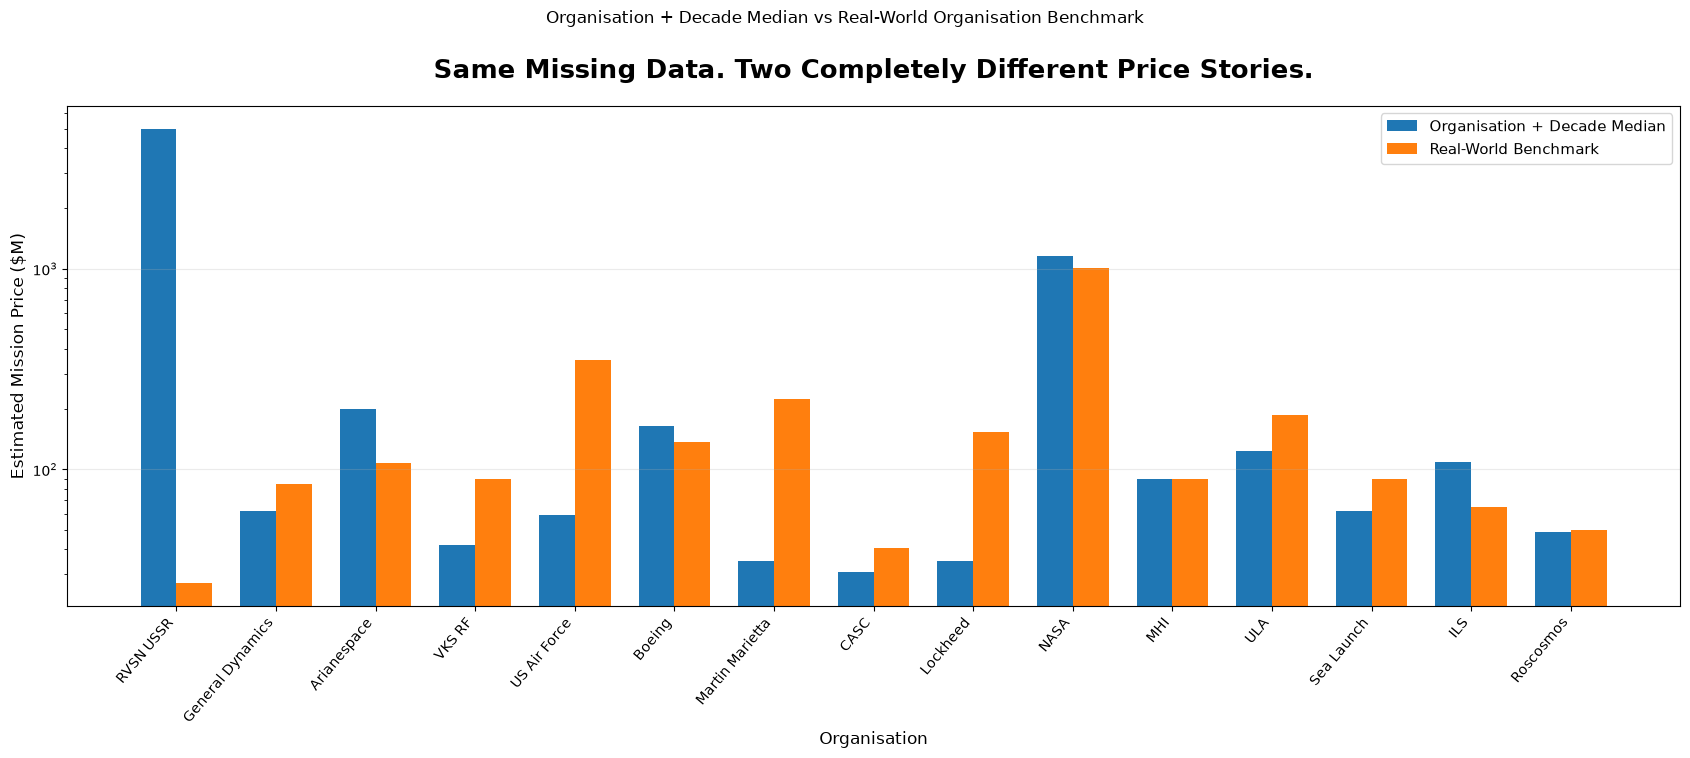

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILES
# ============================================================

original_file = r"orignal.csv"
old_file = r"csv_Final_Bosss.xlsx"
new_file = r"Space_Mission_Data_RealWorld_Imputed.csv"


# ============================================================
# LOAD
# ============================================================

original = pd.read_csv(original_file)
old = pd.read_excel(old_file)
new = pd.read_csv(new_file)


# ============================================================
# CLEAN PRICE
# ============================================================

def clean_price(x):

    return pd.to_numeric(
        x.astype(str)
         .str.replace(",", "", regex=False)
         .str.strip(),
        errors="coerce"
    )


original["Price"] = clean_price(original["Price"])
old["Price"] = clean_price(old["Price"])
new["Price"] = clean_price(new["Price"])


# ============================================================
# IDENTIFY ONLY THE ORIGINAL MISSING PRICES
# ============================================================

missing_mask = original["Price"].isna()

print("=" * 70)
print("ORIGINAL MISSING PRICE RECORDS")
print("=" * 70)

print("Total original missions :", len(original))
print("Originally missing      :", missing_mask.sum())


# ============================================================
# BUILD COMPARISON DATASET
# ============================================================

comparison = pd.DataFrame({

    "Organisation":
        original.loc[missing_mask, "Organisation"].values,

    "Old_Method":
        old.loc[missing_mask, "Price"].values,

    "Real_World":
        new.loc[missing_mask, "Price"].values
})


# ============================================================
# REMOVE ROWS WHERE REAL-WORLD VALUE IS STILL MISSING
# ============================================================

comparison_clean = comparison.dropna(
    subset=["Real_World"]
)


print(
    "Real-world values available:",
    len(comparison_clean)
)

print(
    "Still unresolved:",
    len(comparison) - len(comparison_clean)
)


# ============================================================
# TOP ORGANISATIONS BY ORIGINAL MISSING VALUES
# ============================================================

top_orgs = (
    comparison_clean["Organisation"]
    .value_counts()
    .head(15)
    .index
)


# ============================================================
# ORGANISATION-WISE MEDIAN OF IMPUTED VALUES
# ============================================================

org_comparison = (

    comparison_clean[
        comparison_clean["Organisation"].isin(top_orgs)
    ]

    .groupby("Organisation")

    .agg(
        Old_Method=("Old_Method", "median"),
        Real_World=("Real_World", "median")
    )

    .reindex(top_orgs)
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "=" * 80)
print("ORGANISATION-WISE IMPUTATION COMPARISON")
print("=" * 80)

print(org_comparison.round(2))


# ============================================================
# CINEMATIC GRAPH
# ============================================================

x = np.arange(len(org_comparison))

width = 0.36

fig, ax = plt.subplots(
    figsize=(17, 8)
)


# OLD METHOD

bars1 = ax.bar(
    x - width/2,
    org_comparison["Old_Method"],
    width,
    label="Organisation + Decade Median"
)


# REAL WORLD

bars2 = ax.bar(
    x + width/2,
    org_comparison["Real_World"],
    width,
    label="Real-World Benchmark"
)


# ============================================================
# LOG SCALE
# ============================================================

ax.set_yscale("log")


# ============================================================
# X AXIS
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    org_comparison.index,
    rotation=50,
    ha="right"
)


# ============================================================
# LABELS
# ============================================================

ax.set_ylabel(
    "Estimated Mission Price ($M)",
    fontsize=12
)

ax.set_xlabel(
    "Organisation",
    fontsize=12
)


# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Same Missing Data. Two Completely Different Price Stories.",
    fontsize=19,
    fontweight="bold",
    pad=20
)


# ============================================================
# SUBTITLE
# ============================================================

fig.text(
    0.5,
    0.925,
    "Organisation + Decade Median vs Real-World Organisation Benchmark",
    ha="center",
    fontsize=12
)


# ============================================================
# GRID
# ============================================================

ax.grid(
    axis="y",
    alpha=0.25
)


# ============================================================
# LEGEND
# ============================================================

ax.legend(
    fontsize=11
)


plt.tight_layout(
    rect=[0, 0, 1, 0.90]
)

plt.show()

In [5]:
print(original.columns.tolist())

['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price', 'Mission_Status']



ORIGINAL PRICE AVAILABILITY
Total missions       : 4,324
Originally known     : 964
Originally missing   : 3,360

IMPUTATION COVERAGE
Original missing values : 3,360
Team method filled      : 3,360
Real-world benchmark   : 3,339
Still unresolved       : 21
Benchmark coverage     : 99.38%

ORGANISATION-WISE IMPUTATION COMPARISON
                  Team_Imputation  Real_World_Benchmark  Missing_Missions
Organisation                                                             
RVSN USSR                  5000.0                 27.00              1775
General Dynamics             62.0                 85.00               251
Arianespace                 200.0                107.29               183
VKS RF                       41.8                 90.00               168
US Air Force                 59.0                350.00               135
Boeing                      164.0                137.00               129
Martin Marietta              35.0                225.00               105
CAS

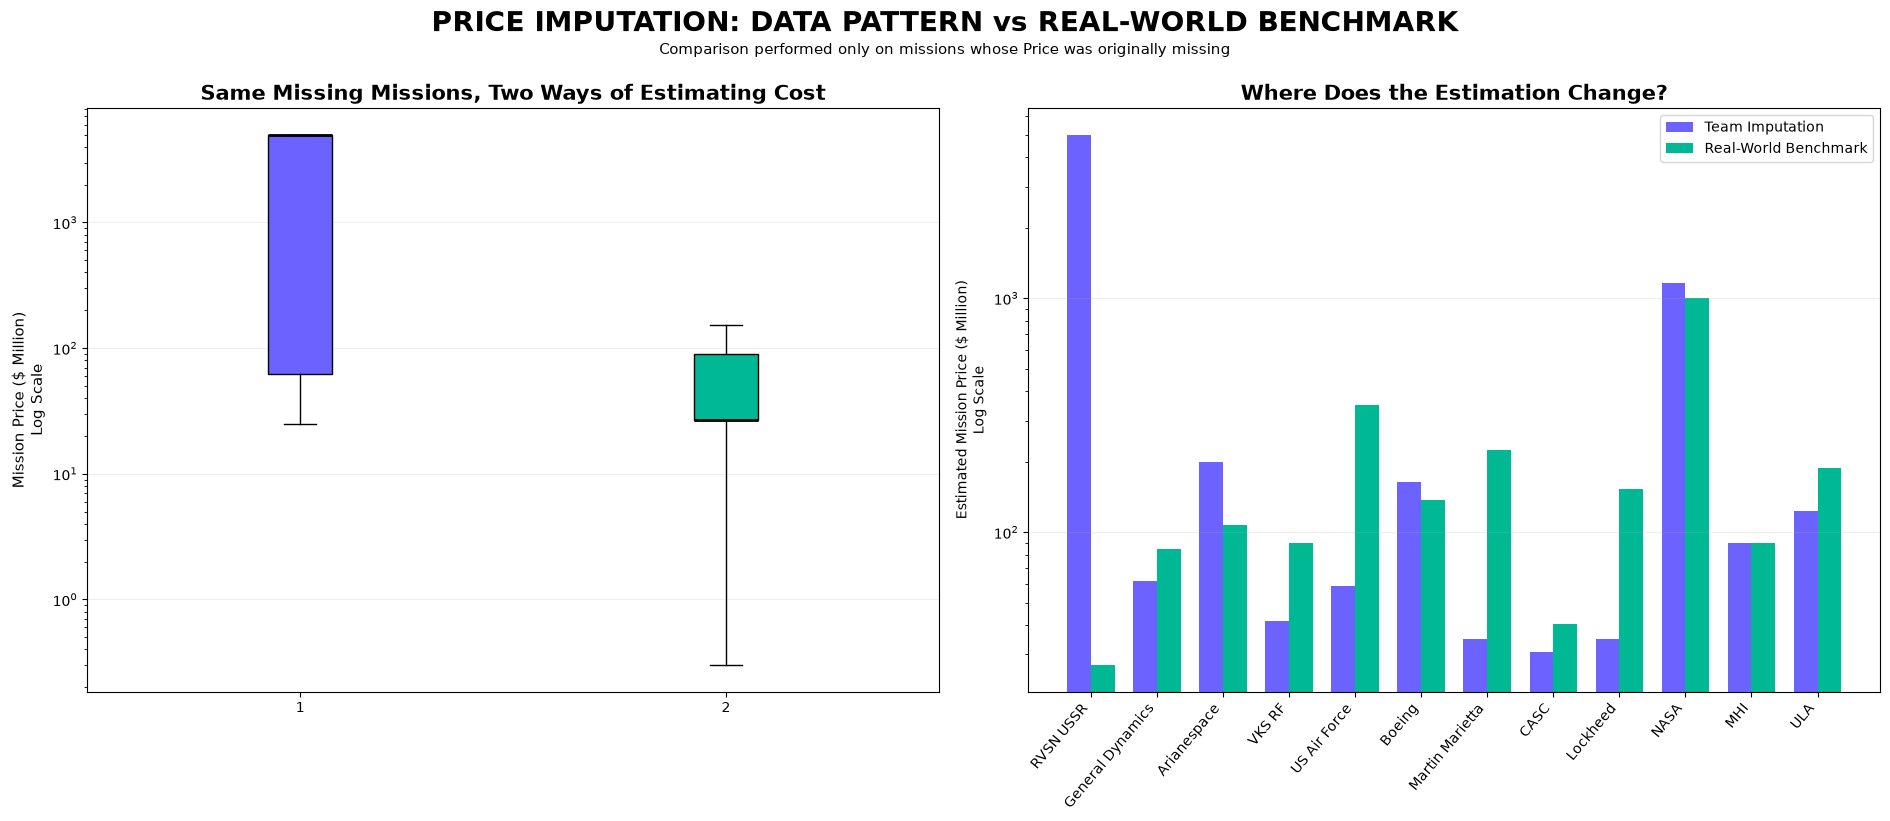


OVERALL COMPARISON
Team method median       : $5,000.00M
Real-world median        : $27.00M

Team method mean         : $2,713.89M
Real-world mean          : $86.45M

Median absolute difference: $4,973.00M
Mean absolute difference  : $2,680.41M

BIGGEST METHOD DISAGREEMENTS
Organisation
RVSN USSR          4973.00
US Air Force        291.00
Martin Marietta     180.32
NASA                178.71
Lockheed            118.00
Arianespace          92.71
ESA                  70.29
ULA                  64.40
Exos                 61.70
OneSpace             58.90
Name: Absolute_Difference, dtype: float64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# FILES
# ============================================================

original_file = r"orignal.csv"

# YOUR EXISTING TEAM-IMPUTED FILE
old_imputed_file = r"Space_Mission_Data_Final.csv"

# REAL-WORLD BENCHMARK FILE
real_world_file = r"Space_Mission_Data_RealWorld_Imputed.csv"


# ============================================================
# LOAD
# ============================================================

original = pd.read_csv(original_file)
old = pd.read_csv(old_imputed_file)
real = pd.read_csv(real_world_file)


# ============================================================
# CLEAN PRICE
# ============================================================

def clean_price(series):

    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.strip(),
        errors="coerce"
    )


original["Price"] = clean_price(original["Price"])
old["Price"] = clean_price(old["Price"])
real["Price"] = clean_price(real["Price"])


# ============================================================
# SAFETY CHECK
# ============================================================

assert len(original) == len(old) == len(real), \
    "ERROR: Dataset row counts do not match."


# ============================================================
# IDENTIFY ORIGINAL MISSING VALUES
# ============================================================

original_missing = original["Price"].isna()


print("\n" + "=" * 75)
print("ORIGINAL PRICE AVAILABILITY")
print("=" * 75)

print(f"Total missions       : {len(original):,}")
print(f"Originally known     : {original['Price'].notna().sum():,}")
print(f"Originally missing   : {original_missing.sum():,}")


# ============================================================
# COMPARE ONLY ORIGINAL NULL VALUES
# ============================================================

comparison = pd.DataFrame({

    "Organisation":
        original.loc[
            original_missing,
            "Organisation"
        ].values,

    "Team_Imputation":
        old.loc[
            original_missing,
            "Price"
        ].values,

    "Real_World_Benchmark":
        real.loc[
            original_missing,
            "Price"
        ].values
})


# ============================================================
# COVERAGE
# ============================================================

team_available = (
    comparison["Team_Imputation"].notna().sum()
)

real_available = (
    comparison["Real_World_Benchmark"].notna().sum()
)

real_unresolved = (
    comparison["Real_World_Benchmark"].isna().sum()
)


print("\n" + "=" * 75)
print("IMPUTATION COVERAGE")
print("=" * 75)

print(
    f"Original missing values : {len(comparison):,}"
)

print(
    f"Team method filled      : {team_available:,}"
)

print(
    f"Real-world benchmark   : {real_available:,}"
)

print(
    f"Still unresolved       : {real_unresolved:,}"
)

print(
    f"Benchmark coverage     : "
    f"{real_available / len(comparison) * 100:.2f}%"
)


# ============================================================
# KEEP ONLY ROWS WHERE BOTH METHODS EXIST
# ============================================================

comparison_clean = comparison.dropna(
    subset=[
        "Team_Imputation",
        "Real_World_Benchmark"
    ]
).copy()


# ============================================================
# DIFFERENCE BETWEEN METHODS
# ============================================================

comparison_clean["Absolute_Difference"] = (
    comparison_clean["Team_Imputation"]
    - comparison_clean["Real_World_Benchmark"]
).abs()


comparison_clean["Difference_%"] = (
    comparison_clean["Absolute_Difference"]
    /
    comparison_clean["Real_World_Benchmark"]
    * 100
)


# ============================================================
# ORGANISATION LEVEL
# ============================================================

org_comparison = (
    comparison_clean
    .groupby("Organisation")
    .agg(

        Team_Imputation=(
            "Team_Imputation",
            "median"
        ),

        Real_World_Benchmark=(
            "Real_World_Benchmark",
            "first"
        ),

        Missing_Missions=(
            "Team_Imputation",
            "count"
        )
    )
)


# ============================================================
# FIND ORGANISATIONS WITH MOST MISSING VALUES
# ============================================================

org_comparison = (
    org_comparison
    .sort_values(
        "Missing_Missions",
        ascending=False
    )
)


# Top 12
plot_data = org_comparison.head(12).copy()


# ============================================================
# PRINT ORGANISATION COMPARISON
# ============================================================

print("\n" + "=" * 90)
print("ORGANISATION-WISE IMPUTATION COMPARISON")
print("=" * 90)

print(
    plot_data.round(2)
)


# ============================================================
# CINEMATIC TWO-PANEL GRAPH
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(19, 8)
)


# ============================================================
# PANEL 1
# DISTRIBUTION
# ============================================================

box_data = [
    comparison_clean["Team_Imputation"],
    comparison_clean["Real_World_Benchmark"]
]

bp = axes[0].boxplot(
    box_data,
    label=[
        "Team\nImputation",
        "Real-World\nBenchmark"
    ],
    patch_artist=True,
    showfliers=False
)


# Custom colours
bp["boxes"][0].set_facecolor("#6C63FF")
bp["boxes"][1].set_facecolor("#00B894")

for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(2)


axes[0].set_yscale("log")

axes[0].set_ylabel(
    "Mission Price ($ Million)\nLog Scale",
    fontsize=11
)

axes[0].set_title(
    "Same Missing Missions, Two Ways of Estimating Cost",
    fontsize=15,
    fontweight="bold"
)

axes[0].grid(
    axis="y",
    alpha=0.20
)


# ============================================================
# PANEL 2
# ORGANISATION COMPARISON
# ============================================================

x = np.arange(
    len(plot_data)
)

width = 0.36


bars1 = axes[1].bar(
    x - width/2,
    plot_data["Team_Imputation"],
    width,
    label="Team Imputation",
    color="#6C63FF"
)


bars2 = axes[1].bar(
    x + width/2,
    plot_data["Real_World_Benchmark"],
    width,
    label="Real-World Benchmark",
    color="#00B894"
)


axes[1].set_yscale("log")

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    plot_data.index,
    rotation=50,
    ha="right"
)

axes[1].set_ylabel(
    "Estimated Mission Price ($ Million)\nLog Scale"
)

axes[1].set_title(
    "Where Does the Estimation Change?",
    fontsize=15,
    fontweight="bold"
)

axes[1].legend()

axes[1].grid(
    axis="y",
    alpha=0.20
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "PRICE IMPUTATION: DATA PATTERN vs REAL-WORLD BENCHMARK",
    fontsize=20,
    fontweight="bold",
    y=1.02
)


fig.text(
    0.5,
    0.965,
    "Comparison performed only on missions whose Price was originally missing",
    ha="center",
    fontsize=11
)


plt.tight_layout()

plt.show()


# ============================================================
# FINAL STATISTICS
# ============================================================

print("\n" + "=" * 75)
print("OVERALL COMPARISON")
print("=" * 75)

print(
    f"Team method median       : "
    f"${comparison_clean['Team_Imputation'].median():,.2f}M"
)

print(
    f"Real-world median        : "
    f"${comparison_clean['Real_World_Benchmark'].median():,.2f}M"
)

print(
    f"\nTeam method mean         : "
    f"${comparison_clean['Team_Imputation'].mean():,.2f}M"
)

print(
    f"Real-world mean          : "
    f"${comparison_clean['Real_World_Benchmark'].mean():,.2f}M"
)

print(
    f"\nMedian absolute difference: "
    f"${comparison_clean['Absolute_Difference'].median():,.2f}M"
)

print(
    f"Mean absolute difference  : "
    f"${comparison_clean['Absolute_Difference'].mean():,.2f}M"
)


# ============================================================
# BIGGEST DISAGREEMENTS
# ============================================================

biggest = (
    comparison_clean
    .groupby("Organisation")
    ["Absolute_Difference"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(10)
)


print("\n" + "=" * 75)
print("BIGGEST METHOD DISAGREEMENTS")
print("=" * 75)

print(
    biggest.round(2)
)

###  Price Analysis — Key Insight

- **Problem:** Large number of missing Price values.
- **Handling:** Organisation Median → Decade Median → Overall Median.
- **Investigation:** Imputation created a strong **$5B concentration**, mainly from RVSN USSR.
- **Validation:** Compared dataset-based estimates with **real-world cost benchmarks**.
- **Finding:** Results vary significantly by imputation method.
- **Conclusion:** **Observed prices are most reliable; imputed prices are estimates and must be interpreted with caution.**

In [6]:
import pandas as pd
import plotly.express as px

# ============================================================
# LOAD FINAL IMPUTED DATA
# ============================================================

df = pd.read_csv(
    r"Space_Mission_Data_RealWorld_Imputed.csv"
)

# If your final file is Excel instead:
# df = pd.read_excel(r"Space_Mission_Data_Final.xlsx")


# ============================================================
# CLEAN
# ============================================================

df["Price"] = pd.to_numeric(
    df["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip(),
    errors="coerce"
)

df["Organisation"] = (
    df["Organisation"]
    .astype(str)
    .str.strip()
)


# Remove rows where Price is still unavailable
df = df.dropna(
    subset=["Price", "Organisation"]
).copy()


# ============================================================
# PRICE BANDS
# ============================================================

def price_band(price):

    if price < 100:
        return "< $100M"

    elif price < 500:
        return "$100M–$500M"

    elif price < 1000:
        return "$500M–$1B"

    elif price < 2000:
        return "$1B–$2B"

    elif price < 5000:
        return "$2B–<$5B"

    else:
        return "$5B"


df["Price_Band"] = df["Price"].apply(
    price_band
)


# ============================================================
# TOP 10 ORGANISATIONS
# ============================================================

top10 = (
    df["Organisation"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)


# ============================================================
# ADD ISRO EVEN IF NOT TOP 10
# ============================================================

if "ISRO" not in top10:
    selected_orgs = top10 + ["ISRO"]
else:
    selected_orgs = top10


print("=" * 70)
print("ORGANISATIONS SHOWN IN SUNBURST")
print("=" * 70)

for i, org in enumerate(selected_orgs, 1):

    count = (
        df["Organisation"]
        .eq(org)
        .sum()
    )

    print(
        f"{i:2}. {org:<25} {count:,} missions"
    )


# ============================================================
# EVERYTHING ELSE = OTHER
# ============================================================

df["Organisation_Display"] = df[
    "Organisation"
].apply(
    lambda x:
        x if x in selected_orgs
        else "Other Organisations"
)


# ============================================================
# AGGREGATE
# ============================================================

sunburst_data = (
    df
    .groupby(
        [
            "Price_Band",
            "Organisation_Display"
        ],
        observed=True
    )
    .size()
    .reset_index(
        name="Mission_Count"
    )
)


# ============================================================
# PRICE BAND ORDER
# ============================================================

band_order = [
    "< $100M",
    "$100M–$500M",
    "$500M–$1B",
    "$1B–$2B",
    "$2B–<$5B",
    "$5B"
]

sunburst_data["Price_Band"] = pd.Categorical(
    sunburst_data["Price_Band"],
    categories=band_order,
    ordered=True
)


# ============================================================
# COLOUR SYSTEM
# ============================================================

color_map = {

    # Major organisations
    "RVSN USSR": "#E63946",
    "Arianespace": "#457B9D",
    "CASC": "#2A9D8F",
    "General Dynamics": "#F4A261",
    "NASA": "#264653",
    "VKS RF": "#8E6C88",
    "US Air Force": "#6C757D",
    "ULA": "#E9C46A",
    "Boeing": "#577590",
    "Martin Marietta": "#F28482",

    # 🇮🇳 ISRO - deliberately highlighted
    "ISRO": "#FF8C00",

    # Everything else
    "Other Organisations": "#BDBDBD"
}


# ============================================================
# SUNBURST
# ============================================================

fig = px.sunburst(
    sunburst_data,

    path=[
        "Price_Band",
        "Organisation_Display"
    ],

    values="Mission_Count",

    color="Organisation_Display",

    color_discrete_map=color_map,

    title=(
        "Mission Cost Structure: "
        "Price Band → Organisation"
    )
)


# ============================================================
# TEXT
# ============================================================

fig.update_traces(
    textinfo="label+percent parent",
    insidetextorientation="auto",
    marker_line_color="white",
    marker_line_width=1.5
)


# ============================================================
# LAYOUT
# ============================================================

fig.update_layout(

    width=1050,
    height=850,

    title={
        "text":
            "Mission Cost Structure: "
            "Price Band → Organisation",
        "x": 0.5,
        "xanchor": "center"
    },

    title_font={
        "size": 22
    },

    margin=dict(
        t=100,
        l=20,
        r=20,
        b=20
    ),

    font=dict(
        size=12
    )
)


fig.show()

ORGANISATIONS SHOWN IN SUNBURST
 1. RVSN USSR                 1,777 missions
 2. Arianespace               279 missions
 3. CASC                      251 missions
 4. General Dynamics          251 missions
 5. NASA                      203 missions
 6. VKS RF                    201 missions
 7. US Air Force              161 missions
 8. ULA                       140 missions
 9. Boeing                    136 missions
10. Martin Marietta           114 missions
11. ISRO                      76 missions
